# DTW-based clustering of LTR identity positional profiles

## Goal

Same structure as `dtw_clusters_full_length.ipynb`, but instead of the
**proportional element count** per positional bin, the profile for each
chromosome × family is the **mean LTR identity per positional bin** — i.e.
how diverged (old) or similar (young) the elements in each chromosomal
window are.

Two parallel analyses:
1. **Per-family** — uses `<Family>_LTR_identity` columns.
2. **All-families pooled** — uses `all_intact_LTR_identity`, to retain
   chromosomes/species that don't have enough elements per individual family.


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import seaborn as sns
import warnings
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import chi2_contingency
from dtaidistance import dtw
warnings.filterwarnings('ignore')

In [2]:
from matplotlib import font_manager
import matplotlib

# Add fonts from the new directory to matplotlib
custom_fonts_path = "config/fonts"
custom_fonts = font_manager.findSystemFonts(fontpaths=custom_fonts_path, fontext='ttf')
for font in custom_fonts:
    try:
        font_manager.fontManager.addfont(font)
    except Exception as e:
        print(f"Skipping font {font} due to error: {e}")

matplotlib.rcParams['font.family'] = "sans-serif"
matplotlib.rcParams['font.sans-serif'] = "Arial"

Skipping font /auto/brno12-cerit/nfs4/home/kratka/brno1/LTR-TE_dynamics/config/fonts/fonts/truetype/noto/NotoColorEmoji.ttf due to error: Can not load face (unknown file format; error code 0x2)


## Parameters

In [4]:
# --- EDIT THESE ---
DATA_DIR        = "data/ratio_tables"
OUTPUT_DIR_FAM  = "data/figures/dtw_identity/per_family"
OUTPUT_DIR_POOL = "data/figures/dtw_identity/pooled"

# Minimum number of positional bins that contain a non-NaN identity value
# for a chromosome × family row to be included.
MIN_VALID_BINS = 30

SPECIES_METADATA = "data/metadata.tsv"

FAMILIES = ["Ale", "Alesia", "Angela", "Bianca", "Ikeros", "Ivana", "SIRE", "TAR", "Tork",
            "CRM", "Reina", "Tekay", "Athila", "Ogre", "Retand"]

EXCLUDED_SPECIES = ["Chamaelirium_luteum"]

SUPERFAMILY = {
    'Ale': 'Copia', 'Alesia': 'Copia', 'Angela': 'Copia', 'Bianca': 'Copia',
    'Ikeros': 'Copia', 'Ivana': 'Copia', 'SIRE': 'Copia', 'TAR': 'Copia', 'Tork': 'Copia',
    'CRM': 'Gypsy', 'Reina': 'Gypsy', 'Tekay': 'Gypsy',
    'Athila': 'Gypsy', 'Ogre': 'Gypsy', 'Retand': 'Gypsy',
}

os.makedirs(OUTPUT_DIR_FAM,  exist_ok=True)
os.makedirs(OUTPUT_DIR_POOL, exist_ok=True)


In [5]:
metadata_df = pd.read_csv(SPECIES_METADATA, sep='\t')
CENTROMERE_TYPE = dict(zip(metadata_df['Species'], metadata_df['Centromere architecture']))

## Step 1: Build input matrices

In [6]:
def load_bin_data(species, data_dir=DATA_DIR):
    filepath = os.path.join(data_dir, f"{species}_percent_counts.tsv")
    return pd.read_csv(filepath, sep='\t')


def get_species_list(metadata=SPECIES_METADATA):
    metadata_df = pd.read_csv(metadata, sep='\t')
    metadata_df = metadata_df[~metadata_df['Species'].isin(EXCLUDED_SPECIES)]
    return sorted(metadata_df['Species'].unique())


### Quick column inspection

Run this cell first to confirm the column names and that the identity values
are in the expected [0, 1] range (or [0, 100] — adjust normalisation below if so).


In [7]:
sp0 = get_species_list()[0]
df0 = load_bin_data(sp0)
id_cols = [c for c in df0.columns if 'LTR_identity' in c]
print(f"Identity columns in {sp0}:")
for c in id_cols:
    vals = df0[c].dropna()
    print(f"  {c:40s}  n_non-nan={len(vals):4d}  min={vals.min():.3f}  max={vals.max():.3f}  mean={vals.mean():.3f}")


Identity columns in Bolboschoenus_planiculmis:
  all_intact_LTR_identity                   n_non-nan=1543  min=71.118  max=100.000  mean=93.722
  Ivana_LTR_identity                        n_non-nan= 692  min=72.689  max=100.000  mean=93.691
  CRM_LTR_identity                          n_non-nan= 116  min=87.676  max=100.000  mean=96.979
  Athila_LTR_identity                       n_non-nan= 122  min=85.397  max=99.703  mean=94.878
  Ikeros_LTR_identity                       n_non-nan= 358  min=73.226  max=100.000  mean=93.743
  Angela_LTR_identity                       n_non-nan= 135  min=73.087  max=99.944  mean=96.946
  Ale_LTR_identity                          n_non-nan= 261  min=80.319  max=100.000  mean=91.952
  Tork_LTR_identity                         n_non-nan= 160  min=78.843  max=100.000  mean=94.917
  Ogre_LTR_identity                         n_non-nan=  39  min=71.118  max=99.952  mean=90.584
  Alesia_LTR_identity                       n_non-nan=   5  min=85.915  max=85.915 

### 1a. Per-family matrix

Each row = one species × chromosome × family.  
Profile = mean LTR identity per positional bin (NaN where no elements in that bin).  
DTW handles NaN by imputing with the row mean before distance computation.


In [34]:
species_list = get_species_list()
print(f"Found {len(species_list)} species")

all_profiles_fam = []
all_metadata_fam = []

for sp in species_list:
    df = load_bin_data(sp)
    chr_sizes = df.groupby('chr')['bin_end'].max().to_dict()

    for chrom, df_chr in df.groupby('chr'):
        df_chr = df_chr.sort_values('bin_ID')

        for fam in FAMILIES:
            col = f"{fam}_LTR_identity"
            if col not in df_chr.columns:
                continue

            identity = df_chr[col].values.astype(float)

            # Skip rows with too few bins carrying identity data
            n_valid = np.sum(np.isfinite(identity))
            if n_valid < MIN_VALID_BINS:
                continue

            # Impute NaN bins with the row mean so DTW can run
            row_mean = np.nanmean(identity)
            identity_filled = np.where(np.isfinite(identity), identity, row_mean)

            # z-score normalization (optional, but can help DTW focus on shape rather than absolute values)
            row_std = np.std(identity_filled)
            if row_std < 0.01:   # deal with near-flat profiles
                identity_filled = np.zeros_like(identity_filled)  # flat profile → zero vector
            else:
                identity_filled = (identity_filled - row_mean) / row_std


            all_profiles_fam.append(identity_filled)
            all_metadata_fam.append({
                'species':      sp,
                'chromosome':   chrom,
                'family':       fam,
                'superfamily':  SUPERFAMILY.get(fam, 'unknown'),
                'n_valid_bins': int(n_valid),
                'row_mean':     float(row_mean),
                'row_std':      float(row_std),
                'chr_size':     chr_sizes.get(chrom, np.nan),
                'centromere':   CENTROMERE_TYPE.get(sp, 'unknown'),
            })

V_fam  = np.array(all_profiles_fam)
meta_fam = pd.DataFrame(all_metadata_fam)

print(f"\nPer-family matrix: {V_fam.shape}  (rows = chr × family, columns = positional bins)")
print(f"Holocentric: {(meta_fam['centromere']=='holocentric').sum()}  |  "
      f"Monocentric: {(meta_fam['centromere']=='monocentric').sum()}  |  "
      f"Unknown: {(meta_fam['centromere']=='unknown').sum()}")
print(f"Families represented: {sorted(meta_fam['family'].unique())}")
print(f"\nFamilies with ZERO qualifying rows:")
for fam in FAMILIES:
    if fam not in meta_fam['family'].unique():
        print(f"  {fam}")


Found 66 species

Per-family matrix: (5978, 97)  (rows = chr × family, columns = positional bins)
Holocentric: 2613  |  Monocentric: 3365  |  Unknown: 0
Families represented: ['Ale', 'Alesia', 'Angela', 'Athila', 'Bianca', 'CRM', 'Ikeros', 'Ivana', 'Ogre', 'Reina', 'Retand', 'SIRE', 'TAR', 'Tekay', 'Tork']

Families with ZERO qualifying rows:


### 1b. Pooled matrix (`all_intact_LTR_identity`)

Each row = one species × chromosome, using the pooled identity column.
Retains chromosomes that would be dropped from the per-family analysis
due to sparse per-family element counts.


In [36]:
all_profiles_pool = []
all_metadata_pool = []

for sp in species_list:
    df = load_bin_data(sp)
    chr_sizes = df.groupby('chr')['bin_end'].max().to_dict()
    col = 'all_intact_LTR_identity'
    if col not in df.columns:
        print(f"WARNING: {col} not found for {sp} — skipping")
        continue

    for chrom, df_chr in df.groupby('chr'):
        df_chr = df_chr.sort_values('bin_ID')
        identity = df_chr[col].values.astype(float)

        n_valid = np.sum(np.isfinite(identity))
        if n_valid < MIN_VALID_BINS:
            continue

        row_mean = np.nanmean(identity)
        identity_filled = np.where(np.isfinite(identity), identity, row_mean)

         # z-score normalization (optional, but can help DTW focus on shape rather than absolute values)
        row_std = np.std(identity_filled)
        if row_std < 0.01:   # deal with near-flat profiles
            identity_filled = np.zeros_like(identity_filled)  # flat profile → zero vector
        else:
            identity_filled = (identity_filled - row_mean) / row_std


        all_profiles_pool.append(identity_filled)
        all_metadata_pool.append({
            'species':       sp,
            'chromosome':    chrom,
            'n_valid_bins':  int(n_valid),
            'row_mean':     float(row_mean),
            'row_std':      float(row_std),
            'chr_size':      chr_sizes.get(chrom, np.nan),
            'centromere':    CENTROMERE_TYPE.get(sp, 'unknown'),
        })

V_pool  = np.array(all_profiles_pool)
meta_pool = pd.DataFrame(all_metadata_pool)

print(f"\nPooled matrix: {V_pool.shape}  (rows = chr, columns = positional bins)")
print(f"Holocentric: {(meta_pool['centromere']=='holocentric').sum()}  |  "
      f"Monocentric: {(meta_pool['centromere']=='monocentric').sum()}")
print(f"Species: {meta_pool['species'].nunique()}")



Pooled matrix: (1492, 97)  (rows = chr, columns = positional bins)
Holocentric: 1098  |  Monocentric: 394
Species: 66


### 1c. Sanity check

In [37]:
for label, V, meta in [("Per-family", V_fam, meta_fam), ("Pooled", V_pool, meta_pool)]:
    print(f"[{label}]  shape={V.shape}  any-NaN={np.any(np.isnan(V))}  "
          f"value range [{V.min():.3f}, {V.max():.3f}]")


[Per-family]  shape=(5978, 97)  any-NaN=False  value range [-9.302, 5.180]
[Pooled]  shape=(1492, 97)  any-NaN=False  value range [-7.745, 4.111]


## Step 2: Compute DTW distance matrices

Same as the spatial-distribution notebook. DTW elastically warps the positional
axis, so a dip in identity (old elements) shifted by a few bins between two
chromosomes is still recognised as the same archetype.


In [38]:
print("Computing DTW — per-family ...")
dist_fam = dtw.distance_matrix_fast(V_fam.astype(np.double))
fin_max = np.nanmax(dist_fam[np.isfinite(dist_fam)])
dist_fam = np.where(np.isfinite(dist_fam), dist_fam, fin_max)
print(f"  range: {dist_fam[dist_fam>0].min():.4f} — {dist_fam.max():.4f}")

print("Computing DTW — pooled ...")
dist_pool = dtw.distance_matrix_fast(V_pool.astype(np.double))
fin_max = np.nanmax(dist_pool[np.isfinite(dist_pool)])
dist_pool = np.where(np.isfinite(dist_pool), dist_pool, fin_max)
print(f"  range: {dist_pool[dist_pool>0].min():.4f} — {dist_pool.max():.4f}")


Computing DTW — per-family ...
  range: 0.7383 — 17.7381
Computing DTW — pooled ...
  range: 1.4086 — 16.5123


## Step 3: Hierarchical clustering

Inspect the dendrograms to choose *k* for each analysis independently.


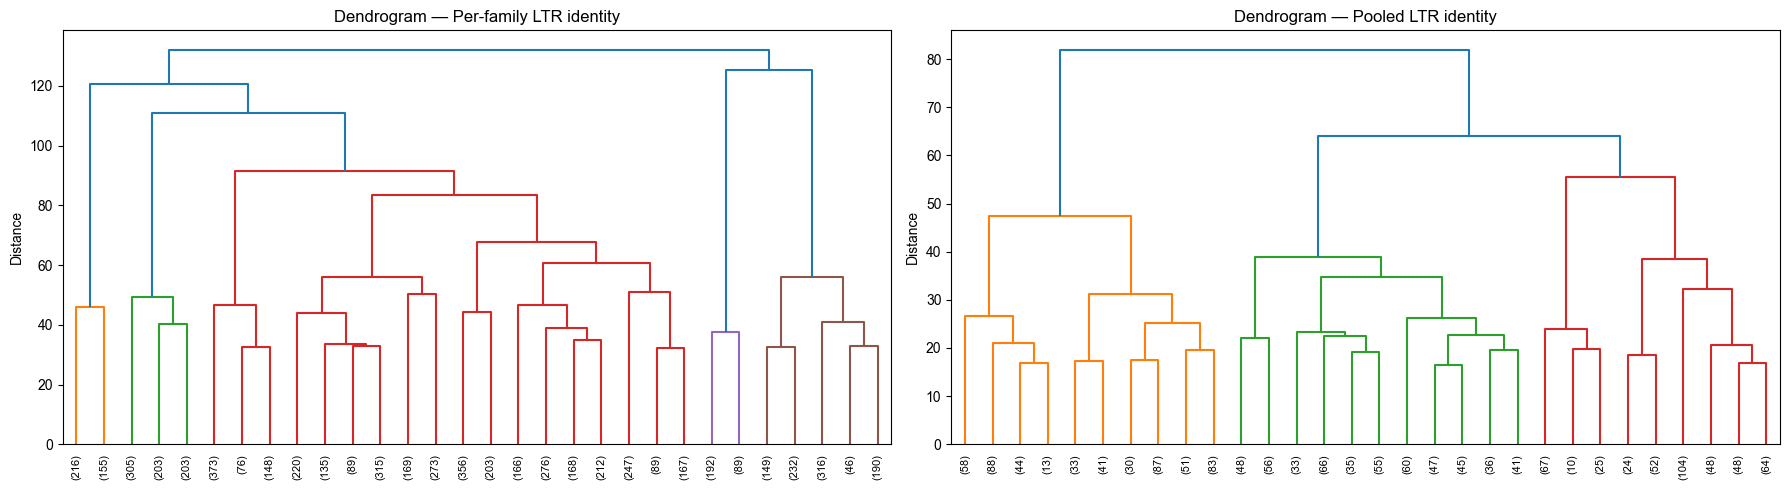

In [39]:
Z_fam  = linkage(squareform(dist_fam),  method='ward')
Z_pool = linkage(squareform(dist_pool), method='ward')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, label, Z, out_dir in [
    (axes[0], "Per-family", Z_fam,  OUTPUT_DIR_FAM),
    (axes[1], "Pooled",     Z_pool, OUTPUT_DIR_POOL),
]:
    dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, leaf_rotation=90, leaf_font_size=8)
    ax.set_title(f'Dendrogram — {label} LTR identity')
    ax.set_ylabel('Distance')
    plt.savefig(os.path.join(out_dir, 'dtw_dendrogram.svg'), dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


### Choose *k* and assign labels

In [45]:
# --- SET K after inspecting dendrograms ---
K_FAM  = 4
K_POOL = 3

meta_fam['cluster']  = fcluster(Z_fam,  t=K_FAM,  criterion='maxclust')
meta_pool['cluster'] = fcluster(Z_pool, t=K_POOL, criterion='maxclust')

print("Per-family sizes:"); print(meta_fam['cluster'].value_counts().sort_index())
print("\nPooled sizes:");    print(meta_pool['cluster'].value_counts().sort_index())


Per-family sizes:
cluster
1     371
2    4393
3     281
4     933
Name: count, dtype: int64

Pooled sizes:
cluster
1    528
2    522
3    442
Name: count, dtype: int64


In [53]:
# --- EDIT LABELS after inspecting centroid plots ---
CLUSTER_LABELS_FAM  = {i+1: f'Cluster {i+1}' for i in range(K_FAM)}
CLUSTER_LABELS_POOL = {i+1: f'Cluster {i+1}' for i in range(K_POOL)}

# Example:
CLUSTER_LABELS_POOL = {1: 'Distal-elevated', 2: 'Uniform', 3: 'Distal-depressed'}


## Step 4: Cluster centroids (archetypes)

Y-axis is **mean LTR identity** (higher = more similar LTRs = younger insertion).
Shaded band = ±1 SD across rows in the cluster.


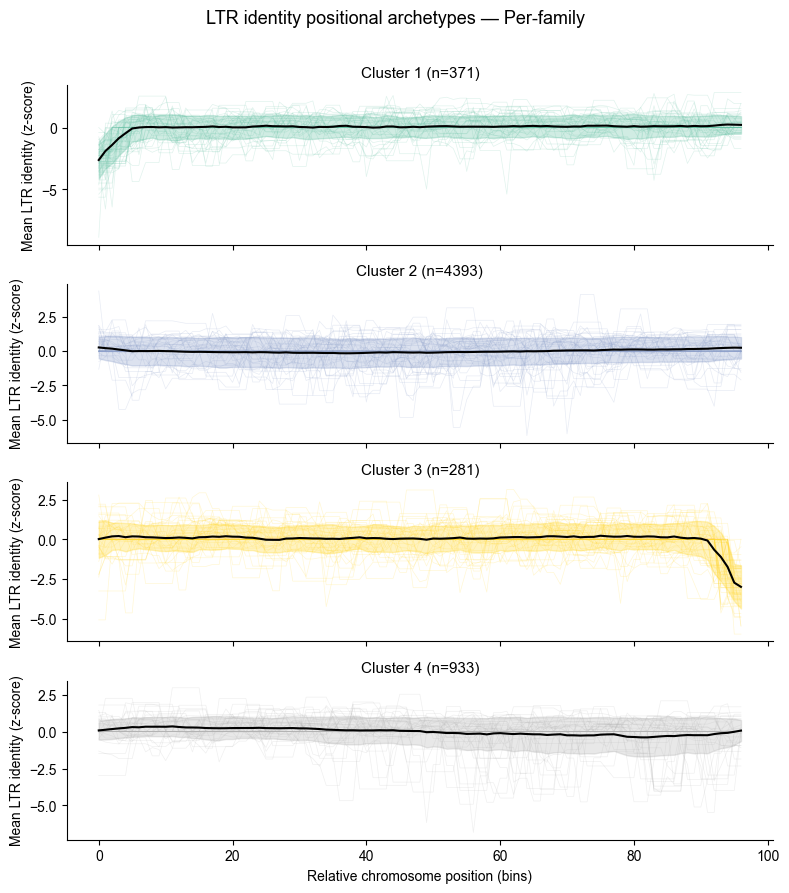

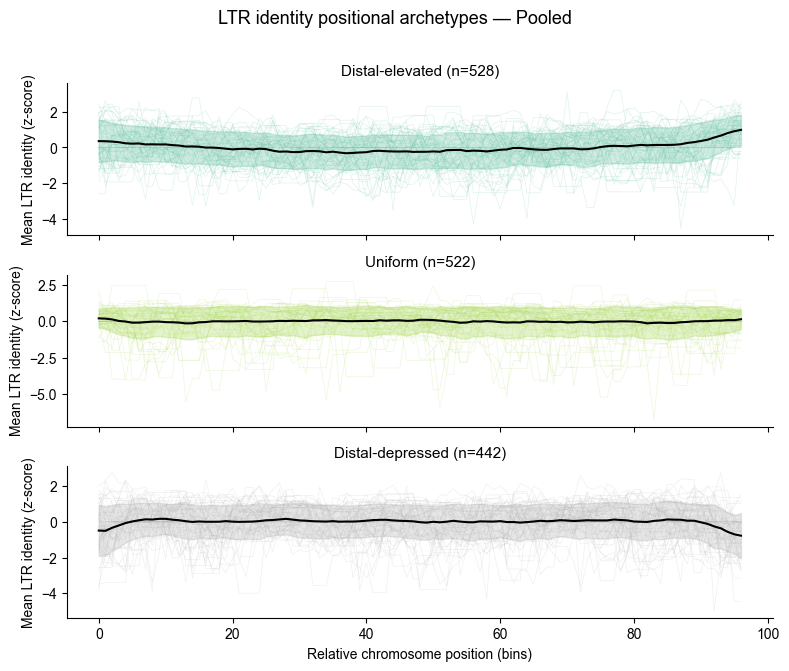

In [56]:
bins_x = np.arange(V_fam.shape[1])

for label, V, meta, K, CLUSTER_LABELS, out_dir in [
    ("Per-family", V_fam,  meta_fam,  K_FAM,  CLUSTER_LABELS_FAM,  OUTPUT_DIR_FAM),
    ("Pooled",     V_pool, meta_pool, K_POOL, CLUSTER_LABELS_POOL, OUTPUT_DIR_POOL),
]:
    colors = plt.get_cmap('Set2')(np.linspace(0, 1, K))
    fig, axes = plt.subplots(K, 1, figsize=(8, 2.2 * K), sharex=True)
    if K == 1: axes = [axes]

    for i, ax in enumerate(axes):
        cluster_id = i + 1
        mask = meta['cluster'] == cluster_id
        cp = V[mask]

        step = max(1, len(cp) // 50)
        for prof in cp[::step]:
            ax.plot(bins_x, prof, color=colors[i], alpha=0.2, lw=0.5)

        mean_prof = cp.mean(axis=0)
        std_prof  = cp.std(axis=0)
        ax.fill_between(bins_x, mean_prof - std_prof, mean_prof + std_prof,
                        color=colors[i], alpha=0.3)
        ax.plot(bins_x, mean_prof, color='black', lw=1.5)

        ax.set_ylabel('Mean LTR identity (z-score)')
        ax.set_title(f'{CLUSTER_LABELS[cluster_id]} (n={mask.sum()})', fontsize=11)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[-1].set_xlabel('Relative chromosome position (bins)')
    fig.suptitle(f'LTR identity positional archetypes — {label}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'dtw_cluster_profiles.svg'), dpi=300, bbox_inches='tight')
    plt.show()


## Step 5: Analysis of cluster membership

### 5a. Holocentric vs monocentric

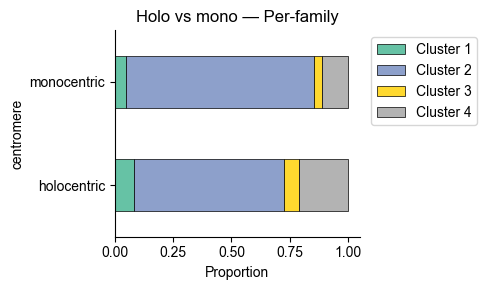

[Per-family] χ²=198.51, df=3, p=0.0000


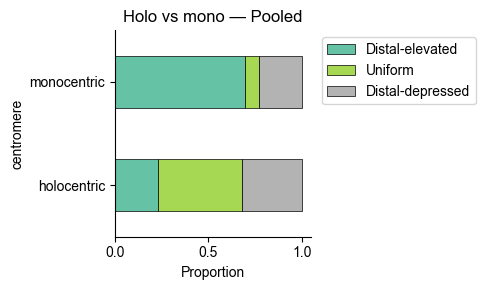

[Pooled] χ²=304.21, df=2, p=0.0000


In [55]:
for label, meta, K, CLUSTER_LABELS, out_dir in [
    ("Per-family", meta_fam,  K_FAM,  CLUSTER_LABELS_FAM,  OUTPUT_DIR_FAM),
    ("Pooled",     meta_pool, K_POOL, CLUSTER_LABELS_POOL, OUTPUT_DIR_POOL),
]:
    colors = plt.get_cmap('Set2')(np.linspace(0, 1, K))
    ct = pd.crosstab(meta['centromere'], meta['cluster'], normalize='index')
    ct.columns = [CLUSTER_LABELS[c] for c in ct.columns]

    fig, ax = plt.subplots(figsize=(5, 3))
    ct.plot(kind='barh', stacked=True, ax=ax, color=colors[:K],
            edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Proportion')
    ax.set_title(f'Holo vs mono — {label}')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'cluster_holo_vs_mono.svg'), bbox_inches='tight')
    plt.show()

    ct_raw = pd.crosstab(meta['centromere'], meta['cluster'])
    chi2, p, dof, _ = chi2_contingency(ct_raw)
    print(f"[{label}] χ²={chi2:.2f}, df={dof}, p={p:.4f}")


### 5b. Cluster membership by TE family (per-family only)

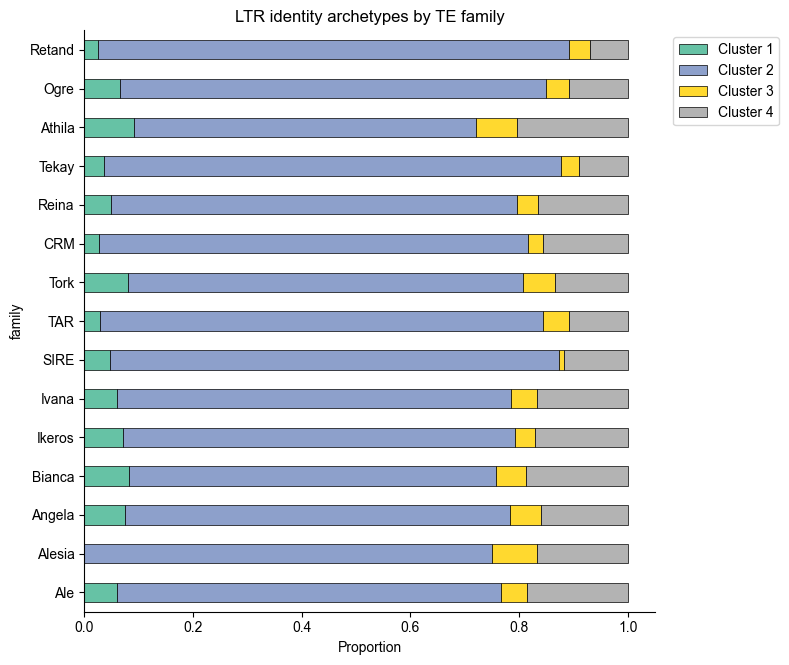

In [49]:
family_order = [f for f in FAMILIES if f in meta_fam['family'].unique()]
colors = plt.get_cmap('Set2')(np.linspace(0, 1, K_FAM))

ct_fam = pd.crosstab(meta_fam['family'], meta_fam['cluster'], normalize='index')
ct_fam.columns = [CLUSTER_LABELS_FAM[c] for c in ct_fam.columns]
ct_fam = ct_fam.reindex(family_order)

fig, ax = plt.subplots(figsize=(8, max(4, len(ct_fam) * 0.45)))
ct_fam.plot(kind='barh', stacked=True, ax=ax, color=colors[:K_FAM],
            edgecolor='black', linewidth=0.5)
ax.set_xlabel('Proportion'); ax.set_title('LTR identity archetypes by TE family')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_FAM, 'cluster_by_family.svg'), bbox_inches='tight')
plt.show()


### 5c. Family × centromere type (per-family only)

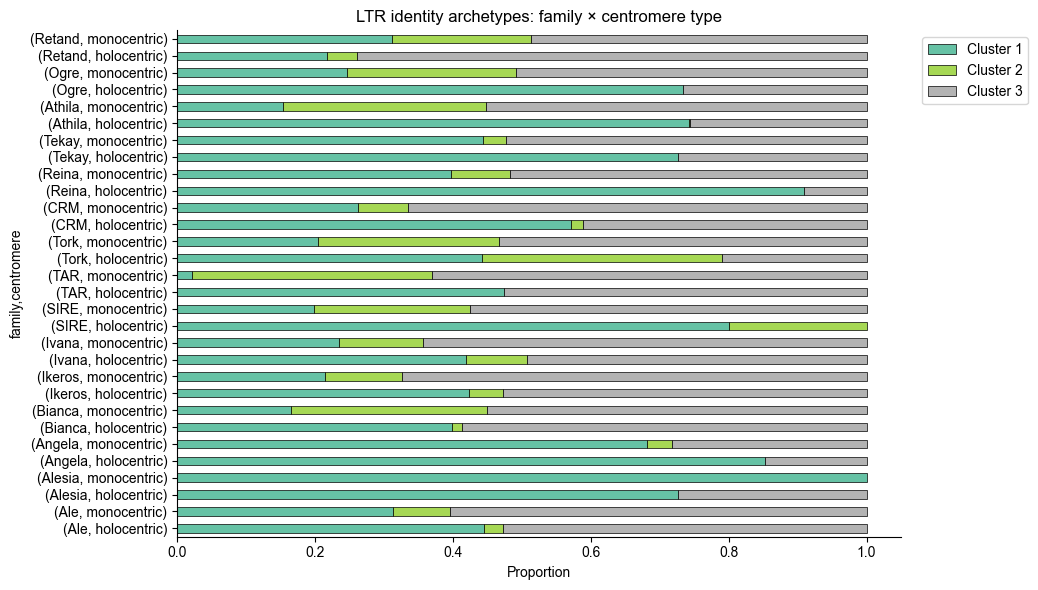

In [21]:
ct_fc = pd.crosstab([meta_fam['family'], meta_fam['centromere']],
                    meta_fam['cluster'], normalize='index')
ct_fc.columns = [CLUSTER_LABELS_FAM[c] for c in ct_fc.columns]

desired_order = [(f, ct) for f in family_order
                 for ct in ['holocentric', 'monocentric']
                 if (f, ct) in ct_fc.index]
ct_fc = ct_fc.reindex(desired_order)

colors = plt.get_cmap('Set2')(np.linspace(0, 1, K_FAM))
fig, ax = plt.subplots(figsize=(max(10, len(ct_fc) * 0.35), 6))
ct_fc.plot(kind='barh', stacked=True, ax=ax, color=colors[:K_FAM],
           edgecolor='black', linewidth=0.5)
ax.set_xlabel('Proportion'); ax.set_title('LTR identity archetypes: family × centromere type')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_FAM, 'cluster_family_x_centromere.svg'), bbox_inches='tight')
plt.show()


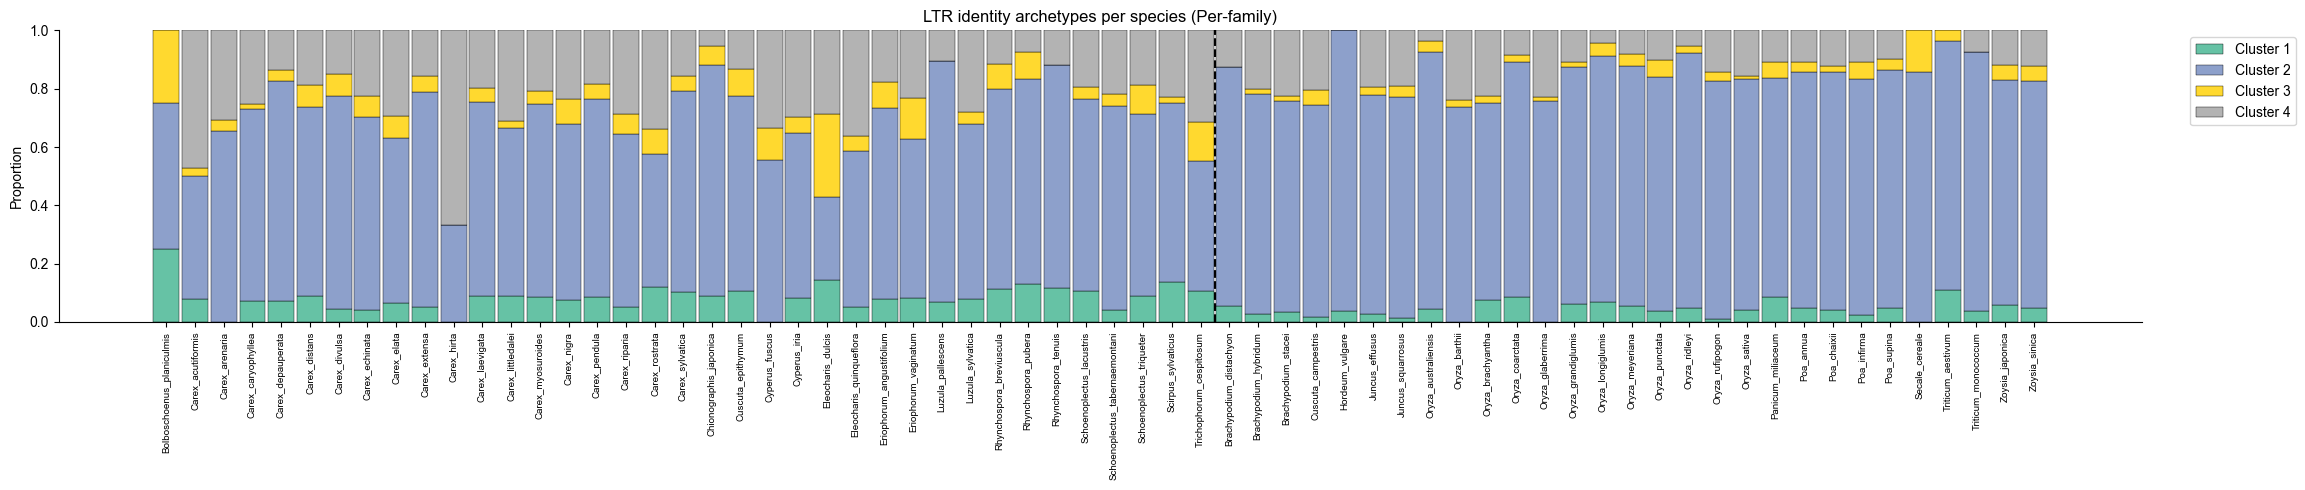

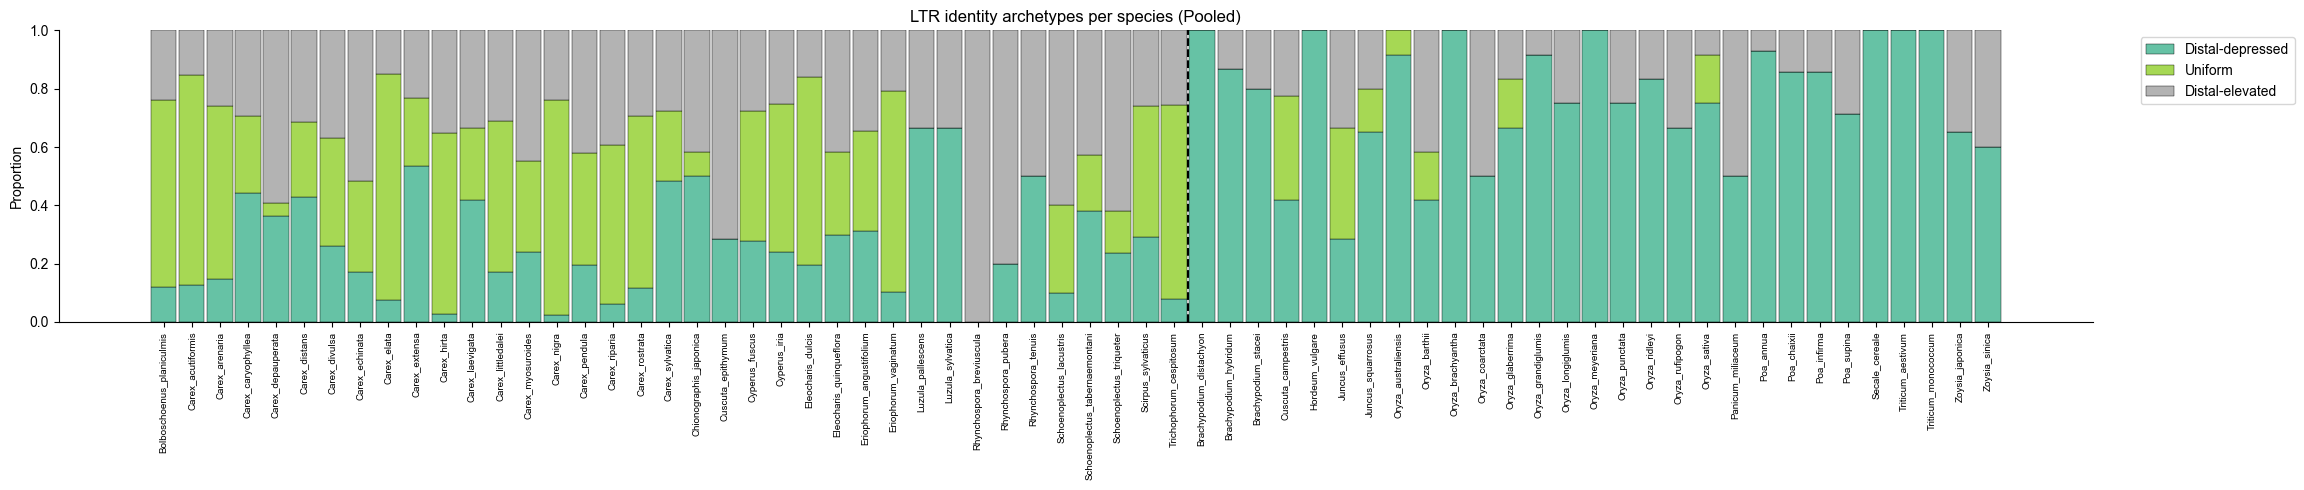

In [51]:
for label, meta, K, CLUSTER_LABELS, out_dir in [
    ("Per-family", meta_fam,  K_FAM,  CLUSTER_LABELS_FAM,  OUTPUT_DIR_FAM),
    ("Pooled",     meta_pool, K_POOL, CLUSTER_LABELS_POOL, OUTPUT_DIR_POOL),
]:
    colors = plt.get_cmap('Set2')(np.linspace(0, 1, K))
    ct_sp = pd.crosstab(meta['species'], meta['cluster'], normalize='index')
    ct_sp.columns = [CLUSTER_LABELS[c] for c in ct_sp.columns]
    ct_sp['centromere'] = ct_sp.index.map(CENTROMERE_TYPE)
    ct_sp = ct_sp.sort_values(['centromere', 'species'], ascending=[True, True])
    centromere_col = ct_sp.pop('centromere')

    fig, ax = plt.subplots(figsize=(max(12, len(ct_sp) * 0.35), 5))
    x = np.arange(len(ct_sp)); bottom = np.zeros(len(ct_sp))
    for j, col in enumerate(ct_sp.columns):
        ax.bar(x, ct_sp[col].values, bottom=bottom, color=colors[j],
               label=col, edgecolor='black', linewidth=0.3, width=0.9)
        bottom += ct_sp[col].values

    ax.set_xticks(x)
    ax.set_xticklabels(ct_sp.index, rotation=90, fontsize=7)
    ax.set_ylabel('Proportion')
    ax.set_title(f'LTR identity archetypes per species ({label})')

    n_holo = (centromere_col == 'holocentric').sum()
    if 0 < n_holo < len(ct_sp):
        ax.axvline(n_holo - 0.5, color='black', lw=1.5, ls='--')

    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, 'cluster_per_species.svg'), bbox_inches='tight')
    plt.show()
